In [ ]:
# Barrido de parámetros — priorización de genoma completo

Validación **leave-one-species-out** sobre las 16 especies del modelo: para cada
una se arma la semilla de druggables *sin* su evidencia, se propaga sobre la capa
de afiliaciones y se mide cuán arriba del ranking quedan sus blancos conocidos.

La grilla es `alpha × beta × lambda × gamma` = **120 combinaciones válidas** por
especie (cuando `lambda` está fijo el modelo no usa `gamma`, así que esas
repeticiones se descartan). La métrica es la AUC parcial en `FPR ≤ 0.10`,
normalizada y corregida por McClish: azar → 0.5, perfecto → 1.0.

Salidas en `gon4/genome_prioritization_out/`: `01_<especie>.csv` (una fila por
combinación) y `01_meta.json`.

**Control** (README §1.3): los óptimos tienen que coincidir con los de
`gon3/resultados/genoma_completo_v5/`, que ya usa la métrica corregida. La
comparación está en la celda 7.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

V4 = "/home/ggiordano/TDR/TDR_2026_v4"
sys.path.insert(0, f"{V4}/comun")
sys.path.insert(0, f"{V4}/genome_prioritization")
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_genome as fg              # el .py de esta carpeta

SALIDAS = tdr.out("genome_prioritization")
FIGURAS = SALIDAS / "figuras"
NB      = "01"                             # numero de este notebook: prefija todo lo que genere
n_core  = 20

plt = tdr.estilo()
SALIDAS

PosixPath('/home/ggiordano/TDR/TDR_2026_v4/gon4/genome_prioritization_out')

## Datos

In [2]:
# Sin cluster_consistent: el barrido usa todos los positivos, como full_genome_v5.
datos = tdr.cargar_db(anotaciones=True, cluster_consistent=False)
datos.st.shape, datos.posdt.shape, datos.sta.shape

· 00_specie_target
· 03_bioactivities_target_compound
· 04a_interpro / 04b_orthomcl


((399353, 3), (248545, 6), (769661, 4))

## Acondicionamiento

In [3]:
spoi   = datos.especies_con_druggables(minimo=10)      # las 16 del modelo
params = fg.PARAMS
combos = fg.grilla_valida(params)

entrada = fg.resumen_especies(datos, spoi)
print(f"{len(spoi)} especies x {len(combos)} combinaciones = {len(spoi)*len(combos)} corridas de nds()")
entrada[["sp_id", "nombre", "grupo", "N", "N_druggable"]]

16 especies x 120 combinaciones = 1920 corridas de nds()


,sp_id,nombre,grupo,N,N_druggable
0,hsap,Homo sapiens,Mamíferos,18052,1985
1,ecol,Escherichia coli,Bacterias,4598,752
2,scer,Saccharomyces cerevisiae,Hongos,6743,533
3,mmus,Mus musculus,Mamíferos,18683,402
4,atha,Arabidopsis thaliana,Plantas,21747,362
5,mtub,Mycobacterium tuberculosis,Bacterias,4083,204
6,dmel,Drosophila melanogaster,Invertebrados,10707,123
7,pfal,Plasmodium falciparum,Protozoos,5495,95
8,tbrt,Trypanosoma brucei,Protozoos,8832,68
9,cele,Caenorhabditis elegans,Invertebrados,27512,63


  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/genome_prioritization_out/figuras/01_f01_positivos_por_especie.pdf


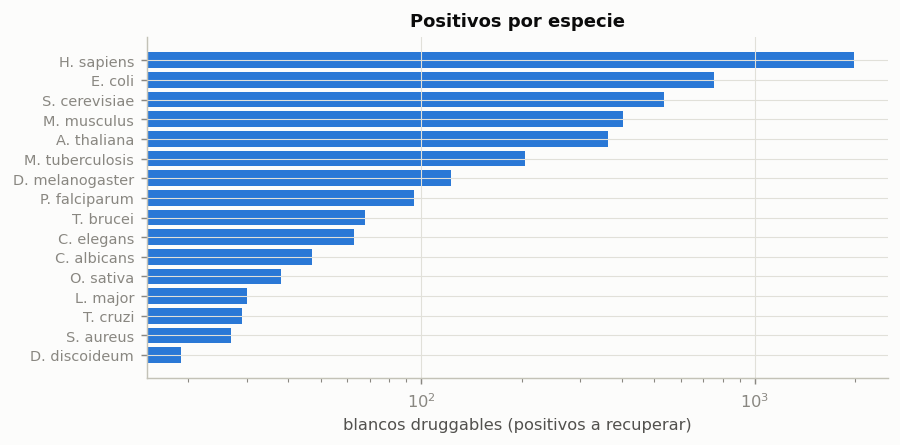

In [4]:
# Vista de los datos de entrada: sobre qué se va a correr el barrido.
fig, ax = plt.subplots(figsize=(7, 3.5), tight_layout=True)
e = entrada.sort_values("N_druggable")
ax.barh(range(len(e)), e["N_druggable"], color=tdr.S1)
ax.set_yticks(range(len(e)))
ax.set_yticklabels([tdr.NOMBRE_CORTO.get(s, s) for s in e["sp_id"]], fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("blancos druggables (positivos a recuperar)")
ax.set_title("Positivos por especie")
tdr.guardar(fig, f"{NB}_f01_positivos_por_especie", FIGURAS)

## Corrida

In [5]:
# celda de corrida: el ciclo se lee aca
import time
for sp in spoi:
    t0  = time.time()
    ctx = fg.preparar_especie(datos, sp)                          # semilla LOSO + cat_rs
    ctx["rs"] = fg.relevance_por_alpha(ctx, params["alpha"])      # RS por alpha, una vez
    fg.fijar_contexto(datos.sta, ctx)                             # visible por fork
    filas = fg.paralelizar(fg.evaluar_combinacion, combos, n_core=n_core, desc=sp)
    fg.guardar_barrido(filas, SALIDAS, NB, sp, params)            # -> 01_<sp>.csv
    print(f"  {sp} en {time.time() - t0:.0f} s", flush=True)

fg.escribir_meta(SALIDAS, NB, notebook="01_barrido_parametros.ipynb",
                 params=params, n_core=n_core, especies=spoi,
                 cluster_consistent=False, metrica="AUC01 = McClish(pAUC(FPR<=0.10))")

[hsap] 120 tareas en 20 procesos
  hsap: 12/120
  hsap: 24/120
  hsap: 36/120
  hsap: 48/120
  hsap: 60/120
  hsap: 72/120
  hsap: 84/120
  hsap: 96/120
  hsap: 108/120
  hsap: 120/120
  hsap: 120 combinaciones -> 01_hsap.csv (AUC01 max 0.5942)
  hsap en 41 s
[ecol] 120 tareas en 20 procesos
  ecol: 12/120
  ecol: 24/120
  ecol: 36/120
  ecol: 48/120
  ecol: 60/120
  ecol: 72/120
  ecol: 84/120
  ecol: 96/120
  ecol: 108/120
  ecol: 120/120
  ecol: 120 combinaciones -> 01_ecol.csv (AUC01 max 0.5880)
  ecol en 40 s
[scer] 120 tareas en 20 procesos
  scer: 12/120
  scer: 24/120
  scer: 36/120
  scer: 48/120
  scer: 60/120
  scer: 72/120
  scer: 84/120
  scer: 96/120
  scer: 108/120
  scer: 120/120
  scer: 120 combinaciones -> 01_scer.csv (AUC01 max 0.5813)
  scer en 40 s
[mmus] 120 tareas en 20 procesos
  mmus: 12/120
  mmus: 24/120
  mmus: 36/120
  mmus: 48/120
  mmus: 60/120
  mmus: 72/120
  mmus: 84/120
  mmus: 96/120
  mmus: 108/120
  mmus: 120/120
  mmus: 120 combinaciones -> 01_mmu

{'notebook': '01_barrido_parametros.ipynb',
 'nb': '01',
 'fecha': '2026-09-07 12:29',
 'params': {'alpha': [0, 0.3, 0.6, 0.9, 1.2],
  'beta': [0, 0.5, 1.0, 1.5],
  'lambda_': [0.0, 0.5, 1.0, None],
  'gamma': [0.8, 1.0, 1.2]},
 'n_core': 20,
 'tablas_db': {'00_specie_target.csv': '2026-06-05',
  '00_specie_target_full.csv': '2026-06-05',
  '01_clusters_fingerprint.csv': '2026-05-13',
  '01_deleted_compounds.csv': '2026-05-13',
  '01_edges_clusters_fingerprint.csv': '2026-05-13',
  '02_clusters_subestructure.csv': '2026-05-13',
  '02_edges_clusters_subestructure.csv': '2026-05-13',
  '03_bioactivities_organism_compound.csv': '2026-06-04',
  '03_bioactivities_target_compound.csv': '2026-08-07',
  '04a_interpro.csv': '2026-06-10',
  '04b_orthomcl.csv': '2026-08-25'},
 'python': '3.12.2',
 'pandas': '2.2.3',
 'especies': ['hsap',
  'ecol',
  'scer',
  'mmus',
  'atha',
  'mtub',
  'dmel',
  'pfal',
  'tbrt',
  'cele',
  'calb',
  'osat',
  'lmaj',
  'tcr',
  'sao',
  'ddis'],
 'cluster_co

# Resultados

In [6]:
# lee de gon4/, no recalcula: esta celda no depende de la de corrida
barrido = fg.cargar_barrido(SALIDAS, NB)
optimos = fg.optimos_por_especie(barrido)
print(tdr.leer_meta(SALIDAS, NB)["fecha"])
optimos[["especie", "AUC01", "AUC", "alpha", "beta", "lambda_", "gamma", "N_targets"]]

2026-09-07 12:29


,especie,AUC01,AUC,alpha,beta,lambda_,gamma,N_targets
0,atha,0.683361,0.828237,0.0,1.0,0.5,0.8,21714
1,calb,0.645299,0.867929,1.2,1.0,0.5,0.8,6040
2,cele,0.663685,0.780799,0.3,1.5,1.0,0.8,27425
3,ddis,0.652077,0.870708,0.0,1.0,1.0,0.8,13088
4,dmel,0.614049,0.811996,0.0,1.0,1.0,0.8,10695
5,ecol,0.587958,0.820488,1.2,1.0,1.0,0.8,4533
6,hsap,0.594217,0.769365,0.0,0.5,1.0,0.8,16301
7,lmaj,0.742940,0.858769,0.0,1.5,0.5,0.8,6564
8,mmus,0.610904,0.817568,0.3,1.0,NaN,0.8,18185
9,mtub,0.580825,0.865912,1.2,1.0,NaN,0.8,4073


In [7]:
# Control (README §1.3): los optimos nuevos contra genoma_completo_v5
control = fg.comparar_con_control(optimos)
print(f"coinciden los parametros optimos en {control['coincide_params'].sum()} de {len(control)} especies")
print(f"|delta AUC01| maximo: {control['delta'].abs().max():.2e}")
control

coinciden los parametros optimos en 16 de 16 especies
|delta AUC01| maximo: 0.00e+00


,especie,auc01_v4,auc01_v5,delta,params_v4,params_v5,coincide_params
0,atha,0.683361,0.683361,0.0,"(0.0, 1.0, 0.5, 0.8)","(0.0, 1.0, 0.5, 0.8)",True
1,calb,0.645299,0.645299,0.0,"(1.2, 1.0, 0.5, 0.8)","(1.2, 1.0, 0.5, 0.8)",True
2,cele,0.663685,0.663685,0.0,"(0.3, 1.5, 1.0, 0.8)","(0.3, 1.5, 1.0, 0.8)",True
3,ddis,0.652077,0.652077,0.0,"(0.0, 1.0, 1.0, 0.8)","(0.0, 1.0, 1.0, 0.8)",True
4,dmel,0.614049,0.614049,0.0,"(0.0, 1.0, 1.0, 0.8)","(0.0, 1.0, 1.0, 0.8)",True
5,ecol,0.587958,0.587958,0.0,"(1.2, 1.0, 1.0, 0.8)","(1.2, 1.0, 1.0, 0.8)",True
6,hsap,0.594217,0.594217,0.0,"(0.0, 0.5, 1.0, 0.8)","(0.0, 0.5, 1.0, 0.8)",True
7,lmaj,0.742940,0.742940,0.0,"(0.0, 1.5, 0.5, 0.8)","(0.0, 1.5, 0.5, 0.8)",True
8,mmus,0.610904,0.610904,0.0,"(0.3, 1.0, None, 0.8)","(0.3, 1.0, None, 0.8)",True
9,mtub,0.580825,0.580825,0.0,"(1.2, 1.0, None, 0.8)","(1.2, 1.0, None, 0.8)",True


  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/genome_prioritization_out/figuras/01_f02_control_v5.pdf


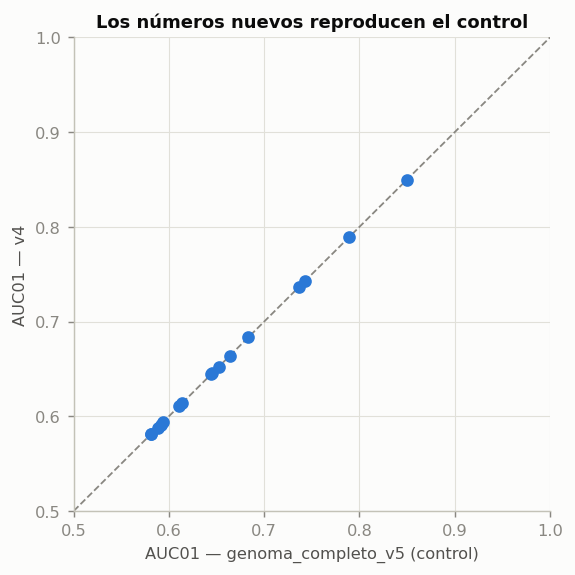

In [8]:
fig, ax = plt.subplots(figsize=(4.5, 4.5), tight_layout=True)
ax.scatter(control["auc01_v5"], control["auc01_v4"], color=tdr.S1, zorder=3)
lims = [0.5, 1.0]
ax.plot(lims, lims, color=tdr.MUTED, ls="--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("AUC01 — genoma_completo_v5 (control)")
ax.set_ylabel("AUC01 — v4")
ax.set_title("Los números nuevos reproducen el control")
tdr.guardar(fig, f"{NB}_f02_control_v5", FIGURAS)

  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/genome_prioritization_out/figuras/01_f03_auc01_por_especie.pdf


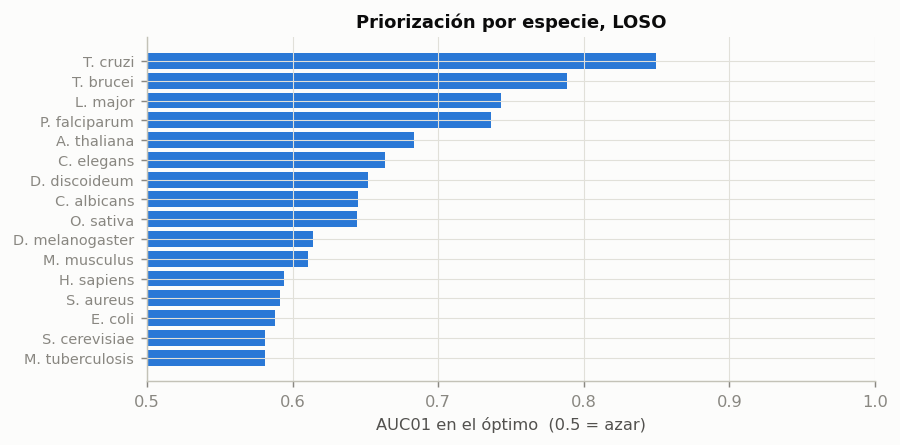

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5), tight_layout=True)
o = optimos.sort_values("AUC01")
ax.barh(range(len(o)), o["AUC01"], color=tdr.S1)
ax.axvline(0.5, color=tdr.MUTED, ls="--", lw=1)
ax.set_yticks(range(len(o)))
ax.set_yticklabels([tdr.NOMBRE_CORTO.get(s, s) for s in o["especie"]], fontsize=8)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("AUC01 en el óptimo  (0.5 = azar)")
ax.set_title("Priorización por especie, LOSO")
tdr.guardar(fig, f"{NB}_f03_auc01_por_especie", FIGURAS)